In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn -q

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [ ]:
import pandas as pd

save_path = '/content/drive/MyDrive/ids_project/data/processed/'

X_train = pd.read_csv(save_path + 'X_train.csv')
X_val   = pd.read_csv(save_path + 'X_val.csv')
X_test  = pd.read_csv(save_path + 'X_test.csv')
X_drift = pd.read_csv(save_path + 'X_drift.csv')

y_train = pd.read_csv(save_path + 'y_train.csv').values.ravel()
y_val   = pd.read_csv(save_path + 'y_val.csv').values.ravel()
y_test  = pd.read_csv(save_path + 'y_test.csv').values.ravel()
y_drift = pd.read_csv(save_path + 'y_drift.csv').values.ravel()

print("Loaded all splits successfully!")

Loaded all splits successfully!


In [ ]:
correlations = X_train.corrwith(pd.Series(y_train)).abs().sort_values(ascending=False)

top_k = 20  # you can tune this later
selected_features = correlations.head(top_k).index.tolist()

print("Top selected features:")
for i, f in enumerate(selected_features, 1):
    print(f"{i:02d}. {f}")

Top selected features:
01. Average Packet Size
02. Flow Duration
03. Packet Length Mean
04. Flow IAT Mean
05. Bwd Packet Length Mean
06. Avg Bwd Segment Size
07. Packet Length Std
08. Flow IAT Max
09. Fwd IAT Max
10. Max Packet Length
11. Fwd IAT Mean
12. Fwd IAT Total
13. Fwd IAT Std
14. Packet Length Variance
15. Flow IAT Std
16. Bwd Packet Length Std
17. Total Length of Bwd Packets
18. Subflow Bwd Bytes
19. Bwd Packet Length Max
20. Fwd Packet Length Std


In [ ]:
X_train_fs = X_train[selected_features]
X_val_fs   = X_val[selected_features]
X_test_fs  = X_test[selected_features]
X_drift_fs = X_drift[selected_features]

print("Feature selection applied to all datasets!")

NameError: name 'X_train' is not defined

In [ ]:
X_train_fs.to_csv(save_path + 'X_train_fs.csv', index=False)
X_val_fs.to_csv(save_path   + 'X_val_fs.csv',   index=False)
X_test_fs.to_csv(save_path  + 'X_test_fs.csv',  index=False)
X_drift_fs.to_csv(save_path + 'X_drift_fs.csv', index=False)

print("Feature-selected datasets saved!")

Feature-selected datasets saved!


In [ ]:
import json

with open(save_path + 'selected_features.json', 'w') as f:
    json.dump(selected_features, f)

print("Feature list saved!")

Feature list saved!


In [ ]:
import pandas as pd

save_path = '/content/drive/MyDrive/ids_project/data/processed/'

X_train = pd.read_csv(save_path + 'X_train_fs.csv')
X_val   = pd.read_csv(save_path + 'X_val_fs.csv')
X_test  = pd.read_csv(save_path + 'X_test_fs.csv')
X_drift = pd.read_csv(save_path + 'X_drift_fs.csv')

y_train = pd.read_csv(save_path + 'y_train.csv').values.ravel()
y_val   = pd.read_csv(save_path + 'y_val.csv').values.ravel()
y_test  = pd.read_csv(save_path + 'y_test.csv').values.ravel()
y_drift = pd.read_csv(save_path + 'y_drift.csv').values.ravel()

print("All datasets loaded!")

All datasets loaded!


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

def evaluate_model(name, model, X, y):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    acc  = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred)
    rec  = recall_score(y, y_pred)
    f1   = f1_score(y, y_pred)
    roc  = roc_auc_score(y, y_prob)

    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"{'='*50}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc:.4f}")

    print("\nConfusion Matrix:")
    print(f"TN: {tn:,} | FP: {fp:,}")
    print(f"FN: {fn:,} | TP: {tp:,}")

    return {
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC": roc
    }

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, n_jobs=-1)

lr.fit(X_train, y_train)

lr_results_test  = evaluate_model("Logistic Regression (Test)", lr, X_test, y_test)
lr_results_drift = evaluate_model("Logistic Regression (Drift)", lr, X_drift, y_drift)


Model: Logistic Regression (Test)
Accuracy:  0.9382
Precision: 0.7996
Recall:    0.7559
F1 Score:  0.7771
ROC-AUC:   0.9260

Confusion Matrix:
TN: 177,353 | FP: 5,764
FN: 7,429 | TP: 23,000

Model: Logistic Regression (Drift)
Accuracy:  0.8121
Precision: 0.0126
Recall:    0.0018
F1 Score:  0.0032
ROC-AUC:   0.7933

Confusion Matrix:
TN: 728,103 | FP: 21,320
FN: 147,161 | TP: 271


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

rf_results_test  = evaluate_model("Random Forest (Test)", rf, X_test, y_test)
rf_results_drift = evaluate_model("Random Forest (Drift)", rf, X_drift, y_drift)

KeyboardInterrupt: 

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss'
)

# TRAIN
xgb.fit(X_train_fs, y_train)

# TEST
xgb_results_test = evaluate_model(
    "XGBoost (Test)", xgb, X_test_fs, y_test
)

# DRIFT
xgb_results_drift = evaluate_model(
    "XGBoost (Drift)", xgb, X_drift_fs, y_drift
)


Model: XGBoost (Test)
Accuracy:  0.9823
Precision: 0.9019
Recall:    0.9828
F1 Score:  0.9406
ROC-AUC:   0.9931

Confusion Matrix:
TN: 179,863 | FP: 3,254
FN: 523 | TP: 29,906

Model: XGBoost (Drift)
Accuracy:  0.8811
Precision: 0.8086
Recall:    0.3626
F1 Score:  0.5007
ROC-AUC:   0.9457

Confusion Matrix:
TN: 736,766 | FP: 12,657
FN: 93,968 | TP: 53,464


In [ ]:
import pandas as pd

# reload FULL cleaned dataset (for labels)
df = pd.read_csv('/content/drive/MyDrive/ids_project/data/processed/cleaned_df.csv')

# extract labels aligned with splits
y_full = df['Binary_Label']
attack_labels = df['Label']
day_col = df['day']

In [ ]:
# recreate same split logic
temp_df = df.copy()

drift_mask = temp_df['day'].str.contains('Thursday|Friday', case=False, na=False)

main_df = temp_df[~drift_mask]
drift_df = temp_df[drift_mask]

from sklearn.model_selection import train_test_split

X_main = main_df.drop(columns=['Label','Binary_Label','day'])
y_main = main_df['Binary_Label']

X_train, X_temp, y_train_idx, y_temp_idx = train_test_split(
    X_main, main_df.index,
    test_size=0.30,
    stratify=y_main,
    random_state=42
)

X_val, X_test, val_idx, test_idx = train_test_split(
    X_temp, y_temp_idx,
    test_size=0.50,
    stratify=y_main.loc[y_temp_idx],
    random_state=42
)

drift_idx = drift_df.index

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

report_path = '/content/drive/MyDrive/ids_project/report/'

def save_conf_matrix(model_name, y_true, y_pred, tag):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt=',', cmap='Blues',
                xticklabels=['BENIGN','ATTACK'],
                yticklabels=['BENIGN','ATTACK'])

    plt.title(f'{model_name} - Confusion Matrix ({tag})')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    file_name = f"{model_name}_{tag}_confusion.png"
    plt.savefig(report_path + file_name, dpi=200)
    plt.close()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def save_metrics_table(model_name, y_true, y_pred, y_prob, tag):
    data = {
        'Metric': ['Accuracy','Precision','Recall','F1','ROC-AUC'],
        'Value': [
            accuracy_score(y_true,y_pred),
            precision_score(y_true,y_pred),
            recall_score(y_true,y_pred),
            f1_score(y_true,y_pred),
            roc_auc_score(y_true,y_prob)
        ]
    }

    df_metrics = pd.DataFrame(data)

    plt.figure(figsize=(6,3))
    plt.axis('off')
    table = plt.table(cellText=df_metrics.values,
                      colLabels=df_metrics.columns,
                      loc='center')

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1,1.5)

    file_name = f"{model_name}_{tag}_metrics.png"
    plt.savefig(report_path + file_name, dpi=200)
    plt.close()

In [ ]:
def save_attack_recall(model_name, y_true, y_pred, indices, tag):
    labels = df.loc[indices, 'Label']

    result = []

    for attack in labels.unique():
        mask = labels == attack

        if attack == 'BENIGN':
            continue

        total = mask.sum()
        caught = ((y_pred[mask] == 1)).sum()
        missed = total - caught

        recall = caught / total if total > 0 else 0

        result.append([attack, total, caught, missed, recall*100])

    attack_df = pd.DataFrame(result,
                            columns=['Attack','Total','Caught','Missed','Recall %'])

    attack_df = attack_df.sort_values(by='Recall %')

    # Save table as image
    plt.figure(figsize=(10,6))
    plt.axis('off')

    table = plt.table(cellText=attack_df.values,
                      colLabels=attack_df.columns,
                      loc='center')

    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1,1.2)

    file_name = f"{model_name}_{tag}_attack_recall.png"
    plt.savefig(report_path + file_name, dpi=200)
    plt.close()

    return attack_df

In [ ]:
# TEST SET
y_pred_test = rf.predict(X_test_fs)
y_prob_test = rf.predict_proba(X_test_fs)[:,1]

save_conf_matrix("RF", y_test, y_pred_test, "test")
save_metrics_table("RF", y_test, y_pred_test, y_prob_test, "test")
save_attack_recall("RF", y_test, y_pred_test, test_idx, "test")


# DRIFT SET
y_pred_drift = rf.predict(X_drift_fs)
y_prob_drift = rf.predict_proba(X_drift_fs)[:,1]

save_conf_matrix("RF", y_drift, y_pred_drift, "drift")
save_metrics_table("RF", y_drift, y_pred_drift, y_prob_drift, "drift")
save_attack_recall("RF", y_drift, y_pred_drift, drift_idx, "drift")

NameError: name 'rf' is not defined

In [ ]:
import json

with open(save_path + 'selected_features.json') as f:
    selected_features = json.load(f)

X_test = X_test[selected_features]

In [ ]:
# TEST SET
y_pred_test = lr.predict(X_test_fs)
y_prob_test = lr.predict_proba(X_test_fs)[:,1]

save_conf_matrix("LR", y_test, y_pred_test, "test")
save_metrics_table("LR", y_test, y_pred_test, y_prob_test, "test")
save_attack_recall("LR", y_test, y_pred_test, test_idx, "test")


# DRIFT SET
y_pred_drift = lr.predict(X_drift_fs)
y_prob_drift = lr.predict_proba(X_drift_fs)[:,1]

save_conf_matrix("LR", y_drift, y_pred_drift, "drift")
save_metrics_table("LR", y_drift, y_pred_drift, y_prob_drift, "drift")
save_attack_recall("LR", y_drift, y_pred_drift, drift_idx, "drift")

,Attack,Total,Caught,Missed,Recall %
3,Web Attack - Sql Injection,21,0,21,0.000000
6,Bot,1431,0,1431,0.000000
5,PortScan,15865,3,15862,0.018910
4,DDoS,127970,100,127870,0.078143
2,Web Attack - XSS,652,17,635,2.607362
1,Web Attack - Brute Force,1457,144,1313,9.883322
0,Infiltration,36,7,29,19.444444


In [ ]:
# TEST SET
y_pred_test = xgb.predict(X_test_fs)
y_prob_test = xgb.predict_proba(X_test_fs)[:,1]

save_conf_matrix("XGB", y_test, y_pred_test, "test")
save_metrics_table("XGB", y_test, y_pred_test, y_prob_test, "test")
save_attack_recall("XGB", y_test, y_pred_test, test_idx, "test")


# DRIFT SET
y_pred_drift = xgb.predict(X_drift_fs)
y_prob_drift = xgb.predict_proba(X_drift_fs)[:,1]

save_conf_matrix("XGB", y_drift, y_pred_drift, "drift")
save_metrics_table("XGB", y_drift, y_pred_drift, y_prob_drift, "drift")
save_attack_recall("XGB", y_drift, y_pred_drift, drift_idx, "drift")

,Attack,Total,Caught,Missed,Recall %
0,Infiltration,36,0,36,0.000000
1,Web Attack - Brute Force,1457,0,1457,0.000000
6,Bot,1431,0,1431,0.000000
2,Web Attack - XSS,652,2,650,0.306748
5,PortScan,15865,168,15697,1.058935
3,Web Attack - Sql Injection,21,1,20,4.761905
4,DDoS,127970,53293,74677,41.644917


In [ ]:
!pip install imbalanced-learn

from imblearn.over_sampling import SMOTE
from collections import Counter

In [ ]:
# assuming top_features already exists
X_train = X_train[selected_features]
X_val   = X_val[selected_features]
X_test  = X_test[selected_features]
X_drift = X_drift[selected_features]

In [ ]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [ ]:
from sklearn.linear_model import LogisticRegression
lr_smote = LogisticRegression(max_iter=1000)
lr_smote.fit(X_train_smote, y_train_smote)

LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_smote = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(X_train_smote, y_train_smote)

RandomForestClassifier(max_depth=10, n_jobs=-1, random_state=42)

In [ ]:
# RANDOM FOREST (SMOTE)

# TEST
y_pred_test = rf_smote.predict(X_test)
y_prob_test = rf_smote.predict_proba(X_test)[:,1]

save_conf_matrix("RF_SMOTE", y_test, y_pred_test, "test")
save_metrics_table("RF_SMOTE", y_test, y_pred_test, y_prob_test, "test")
save_attack_recall("RF_SMOTE", y_test, y_pred_test, test_idx, "test")

# DRIFT
y_pred_drift = rf_smote.predict(X_drift)
y_prob_drift = rf_smote.predict_proba(X_drift)[:,1]

save_conf_matrix("RF_SMOTE", y_drift, y_pred_drift, "drift")
save_metrics_table("RF_SMOTE", y_drift, y_pred_drift, y_prob_drift, "drift")
save_attack_recall("RF_SMOTE", y_drift, y_pred_drift, drift_idx, "drift")

,Attack,Total,Caught,Missed,Recall %
5,PortScan,15865,86,15779,0.542074
3,Web Attack - Sql Injection,21,5,16,23.809524
6,Bot,1431,530,901,37.037037
4,DDoS,127970,68094,59876,53.210909
0,Infiltration,36,24,12,66.666667
1,Web Attack - Brute Force,1457,1363,94,93.548387
2,Web Attack - XSS,652,624,28,95.705521


In [ ]:
from xgboost import XGBClassifier
xgb_smote = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss'
)

xgb_smote.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
def evaluate_model(name, model, X, y, dataset_type):

    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:,1]

    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred)
    rec = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    roc = roc_auc_score(y, y_prob)

    print(f"\n=== {name} ({dataset_type}) ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc:.4f}")

    # save metrics table
    metrics_df = pd.DataFrame({
        "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
        "Value": [acc, prec, rec, f1, roc]
    })

    metrics_df.to_csv(f"/content/drive/MyDrive/ids_project/report/{name}_{dataset_type}_metrics.csv", index=False)

    return y_pred, y_prob

In [ ]:
from sklearn.metrics import confusion_matrix

def save_conf_matrix(name, y_true, y_pred, dataset_type):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{name} - {dataset_type}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    path = f"/content/drive/MyDrive/ids_project/report/{name}_{dataset_type}_cm.png"
    plt.savefig(path)
    plt.close()

In [ ]:
def save_attack_recall(name, y_true, y_pred, indices, dataset_type):

    df_temp = df.loc[indices].copy()
    df_temp['y_true'] = y_true
    df_temp['y_pred'] = y_pred

    attacks = df_temp[df_temp['Label'] != 'BENIGN']['Label'].unique()

    results = []

    for attack in attacks:
        subset = df_temp[df_temp['Label'] == attack]

        total = len(subset)
        caught = ((subset['y_true']==1) & (subset['y_pred']==1)).sum()
        missed = total - caught

        recall = caught / total if total > 0 else 0

        results.append([attack, total, caught, missed, recall*100])

    res_df = pd.DataFrame(results, columns=["Attack", "Total", "Caught", "Missed", "Recall %"])

    res_df.to_csv(f"/content/drive/MyDrive/ids_project/report/{name}_{dataset_type}_attack_recall.csv", index=False)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

In [ ]:
# TEST
y_pred_test, y_prob_test = evaluate_model("LR_SMOTE", lr_smote, X_test, y_test, "test")
save_conf_matrix("LR_SMOTE", y_test, y_pred_test, "test")
save_attack_recall("LR_SMOTE", y_test, y_pred_test, test_idx, "test")

# DRIFT
y_pred_drift, y_prob_drift = evaluate_model("LR_SMOTE", lr_smote, X_drift, y_drift, "drift")
save_conf_matrix("LR_SMOTE", y_drift, y_pred_drift, "drift")
save_attack_recall("LR_SMOTE", y_drift, y_pred_drift, drift_idx, "drift")


=== LR_SMOTE (test) ===
Accuracy:  0.7886
Precision: 0.3961
Recall:    0.9219
F1 Score:  0.5541
ROC-AUC:   0.9145

=== LR_SMOTE (drift) ===
Accuracy:  0.7180
Precision: 0.0000
Recall:    0.0000
F1 Score:  0.0000
ROC-AUC:   0.4406


In [ ]:
# TEST
y_pred_test, y_prob_test = evaluate_model("XGB_SMOTE", xgb_smote, X_test, y_test, "test")
save_conf_matrix("XGB_SMOTE", y_test, y_pred_test, "test")
save_attack_recall("XGB_SMOTE", y_test, y_pred_test, test_idx, "test")

# DRIFT
y_pred_drift, y_prob_drift = evaluate_model("XGB_SMOTE", xgb_smote, X_drift, y_drift, "drift")
save_conf_matrix("XGB_SMOTE", y_drift, y_pred_drift, "drift")
save_attack_recall("XGB_SMOTE", y_drift, y_pred_drift, drift_idx, "drift")


=== XGB_SMOTE (test) ===
Accuracy:  0.9801
Precision: 0.8842
Recall:    0.9897
F1 Score:  0.9340
ROC-AUC:   0.9929

=== XGB_SMOTE (drift) ===
Accuracy:  0.8356
Precision: 0.0000
Recall:    0.0000
F1 Score:  0.0000
ROC-AUC:   0.7072


In [ ]:
from sklearn.linear_model import LogisticRegression

lr_weighted = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

lr_weighted.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
# TEST
y_pred_test, y_prob_test = evaluate_model("LR_WEIGHTED", lr_weighted, X_test, y_test, "test")
save_conf_matrix("LR_WEIGHTED", y_test, y_pred_test, "test")
save_attack_recall("LR_WEIGHTED", y_test, y_pred_test, test_idx, "test")

# DRIFT
y_pred_drift, y_prob_drift = evaluate_model("LR_WEIGHTED", lr_weighted, X_drift, y_drift, "drift")
save_conf_matrix("LR_WEIGHTED", y_drift, y_pred_drift, "drift")
save_attack_recall("LR_WEIGHTED", y_drift, y_pred_drift, drift_idx, "drift")


=== LR_WEIGHTED (test) ===
Accuracy:  0.7867
Precision: 0.3927
Recall:    0.9096
F1 Score:  0.5485
ROC-AUC:   0.9126

=== LR_WEIGHTED (drift) ===
Accuracy:  0.7199
Precision: 0.0000
Recall:    0.0000
F1 Score:  0.0000
ROC-AUC:   0.4499


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_weighted = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_weighted.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=15, n_jobs=-1,
                       random_state=42)

In [ ]:
# TEST
y_pred_test, y_prob_test = evaluate_model("RF_WEIGHTED",rf_weighted, X_test, y_test, "test")
save_conf_matrix("RF_WEIGHTED", y_test, y_pred_test, "test")
save_attack_recall("RF_WEIGHTED", y_test, y_pred_test, test_idx, "test")

# DRIFT
y_pred_drift, y_prob_drift = evaluate_model("RF_WEIGHTED", rf_weighted, X_drift, y_drift, "drift")
save_conf_matrix("RF_WEIGHTED", y_drift, y_pred_drift, "drift")
save_attack_recall("RF_WEIGHTED", y_drift, y_pred_drift, drift_idx, "drift")


=== RF_WEIGHTED (test) ===
Accuracy:  0.9824
Precision: 0.8970
Recall:    0.9904
F1 Score:  0.9414
ROC-AUC:   0.9933

=== RF_WEIGHTED (drift) ===
Accuracy:  0.7674
Precision: 0.3436
Recall:    0.4559
F1 Score:  0.3918
ROC-AUC:   0.5142


In [ ]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 6.017809608315376


In [ ]:
from xgboost import XGBClassifier

xgb_weighted = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb_weighted.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# TEST
y_pred_test, y_prob_test = evaluate_model("XGB_WEIGHTED", xgb_weighted, X_test, y_test, "test")
save_conf_matrix("XGB_WEIGHTED", y_test, y_pred_test, "test")
save_attack_recall("XGB_WEIGHTED", y_test, y_pred_test, test_idx, "test")

# DRIFT
y_pred_drift, y_prob_drift = evaluate_model("XGB_WEIGHTED", xgb_weighted, X_drift, y_drift, "drift")
save_conf_matrix("XGB_WEIGHTED", y_drift, y_pred_drift, "drift")
save_attack_recall("XGB_WEIGHTED", y_drift, y_pred_drift, drift_idx, "drift")


=== XGB_WEIGHTED (test) ===
Accuracy:  0.9800
Precision: 0.8834
Recall:    0.9906
F1 Score:  0.9339
ROC-AUC:   0.9928

=== XGB_WEIGHTED (drift) ===
Accuracy:  0.8356
Precision: 0.0000
Recall:    0.0000
F1 Score:  0.0000
ROC-AUC:   0.5881


In [ ]:
import numpy as np

def predict_with_threshold(model, X, threshold=0.5):
    probs = model.predict_proba(X)[:, 1]
    preds = (probs >= threshold).astype(int)
    return preds, probs

In [ ]:
thresholds = [0.5, 0.4, 0.3, 0.2]

for t in thresholds:
    print(f"\n--- Threshold: {t} ---")

    y_pred_t, y_prob_t = predict_with_threshold(lr_weighted, X_test, t)

    print("Recall:", recall_score(y_test, y_pred_t))
    print("Precision:", precision_score(y_test, y_pred_t))


--- Threshold: 0.5 ---
Recall: 0.9095599592494003
Precision: 0.3926706770330855

--- Threshold: 0.4 ---
Recall: 0.991159748923724
Precision: 0.2767785037809265

--- Threshold: 0.3 ---
Recall: 0.9927043281080549
Precision: 0.22551120202465116

--- Threshold: 0.2 ---
Recall: 0.9935587761674718
Precision: 0.19949849879573725


In [ ]:
thresholds = [0.5, 0.4, 0.3, 0.2]

for t in thresholds:
    print(f"\n--- Threshold: {t} ---")

    y_pred_t, y_prob_t = predict_with_threshold(rf_weighted, X_test, t)

    print("Recall:", recall_score(y_test, y_pred_t))
    print("Precision:", precision_score(y_test, y_pred_t))


--- Threshold: 0.5 ---
Recall: 0.9903710276381084
Precision: 0.8970115489939279

--- Threshold: 0.4 ---
Recall: 0.9916198363403332
Precision: 0.8889347160028281

--- Threshold: 0.3 ---
Recall: 0.9935916395543725
Precision: 0.8769578837452141

--- Threshold: 0.2 ---
Recall: 0.9956620329291137
Precision: 0.840929277228822


In [ ]:
thresholds = [0.5, 0.4, 0.3, 0.2]

for t in thresholds:
    print(f"\n--- Threshold: {t} ---")

    y_pred_t, y_prob_t = predict_with_threshold(xgb_weighted, X_test, t)

    print("Recall:", recall_score(y_test, y_pred_t))
    print("Precision:", precision_score(y_test, y_pred_t))


--- Threshold: 0.5 ---
Recall: 0.990601071346413
Precision: 0.8833890158841803

--- Threshold: 0.4 ---
Recall: 0.9918827434355385
Precision: 0.8742070963070239

--- Threshold: 0.3 ---
Recall: 0.9930000985901607
Precision: 0.8595323434033112

--- Threshold: 0.2 ---
Recall: 0.9959578034112195
Precision: 0.818948278657515


In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_final = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train, y_train)

print("Final RF model trained!")

Final RF model trained!


In [ ]:
import numpy as np

def predict_with_threshold(model, X, threshold=0.3):
    probs = model.predict_proba(X)[:, 1]
    preds = (probs >= threshold).astype(int)
    return preds, probs

In [ ]:
y_pred_test, y_prob_test = predict_with_threshold(rf_final, X_test, 0.3)

save_conf_matrix("RF_FINAL", y_test, y_pred_test, "test")
save_metrics_table("RF_FINAL", y_test, y_pred_test, y_prob_test, "test")
save_attack_recall("RF_FINAL", y_test, y_pred_test, test_idx, "test")

In [ ]:
y_pred_drift, y_prob_drift = predict_with_threshold(rf_final, X_drift, 0.3)

save_conf_matrix("RF_FINAL", y_drift, y_pred_drift, "drift")
save_metrics_table("RF_FINAL", y_drift, y_pred_drift, y_prob_drift, "drift")
save_attack_recall("RF_FINAL", y_drift, y_pred_drift, drift_idx, "drift")

In [ ]:
import joblib
import os

model_path = "/content/drive/MyDrive/ids_project/models/"
os.makedirs(model_path, exist_ok=True)

# Save model
joblib.dump(rf_final, model_path + "rf_final.pkl")

# Save selected features
joblib.dump(selected_features, model_path + "features.pkl")

print("All final components saved!")

All final components saved!


In [6]:
import pandas as pd
import joblib

save_path  = '/content/drive/MyDrive/ids_project/data/processed/'
model_path = '/content/drive/MyDrive/ids_project/models/'

X_train = pd.read_csv(save_path + 'X_train.csv')
X_val   = pd.read_csv(save_path + 'X_val.csv')
X_test  = pd.read_csv(save_path + 'X_test.csv')
X_drift = pd.read_csv(save_path + 'X_drift.csv')

y_train = pd.read_csv(save_path + 'y_train.csv').values.ravel()
y_val   = pd.read_csv(save_path + 'y_val.csv').values.ravel()
y_test  = pd.read_csv(save_path + 'y_test.csv').values.ravel()
y_drift = pd.read_csv(save_path + 'y_drift.csv').values.ravel()

print("Data loaded!")

Data loaded!


In [13]:
selected_features = joblib.load(model_path + 'features.pkl')

In [14]:
X_train = X_train[selected_features]
X_val   = X_val[selected_features]
X_test  = X_test[selected_features]
X_drift = X_drift[selected_features]

print("Feature alignment done!")
print(X_train.shape)  # should be (n, 20)

Feature alignment done!
(996543, 20)


In [15]:
print(X_train.columns.equals(X_test.columns))

True


In [16]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)
X_drift_scaled = scaler.transform(X_drift)

In [17]:
import joblib


joblib.dump(scaler, model_path + 'scaler.pkl')


print("SCALER")

SCALER


In [21]:
sample = X_test.iloc[[0]]
sample_scaled = scaler.transform(sample)

print(rf_final.predict(sample_scaled))

[0]


In [25]:
!pip install shap

In [7]:
import shap
import joblib
import pandas as pd

model = joblib.load(model_path + "rf_final.pkl")
scaler = joblib.load(model_path + "scaler.pkl")
features = joblib.load(model_path + "features.pkl")

X_sample = pd.read_csv(save_path + "X_test.csv")[features]
X_sample_scaled = scaler.transform(X_sample)

In [22]:
print(rf_final.predict(sample_scaled))
print(rf_final.predict_proba(sample_scaled))

[0]
[[1. 0.]]


In [24]:
sample2 = X_test.iloc[[1000]]
sample2_scaled = scaler.transform(sample2)

print(rf_final.predict(sample2_scaled))
print(rf_final.predict_proba(sample2_scaled))

[1]
[[0.0201614 0.9798386]]


In [30]:
import shap

explainer = shap.TreeExplainer(model)

# use small subset
X_small = X_sample_scaled[:300]

shap_values = explainer.shap_values(X_small)





In [29]:
print(type(shap_values))
print(len(shap_values) if isinstance(shap_values, list) else "Not a list")
print("Shape:", getattr(shap_values, "shape", "No shape"))

<class 'numpy.ndarray'>
Not a list
Shape: (20, 2)


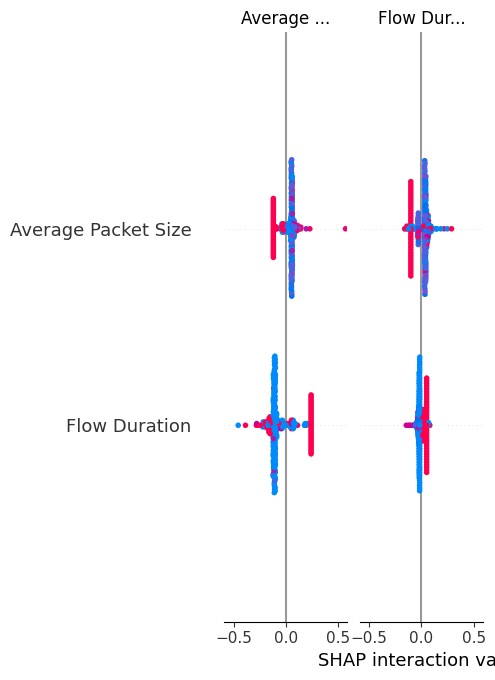

In [31]:


shap.summary_plot(shap_values, X_small, feature_names=selected_features)

In [32]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(model)

# small sample
X_small = X_test_scaled[:300]

shap_values = explainer.shap_values(X_small)

# handle shape automatically
if isinstance(shap_values, list):
    shap_values = shap_values[1]

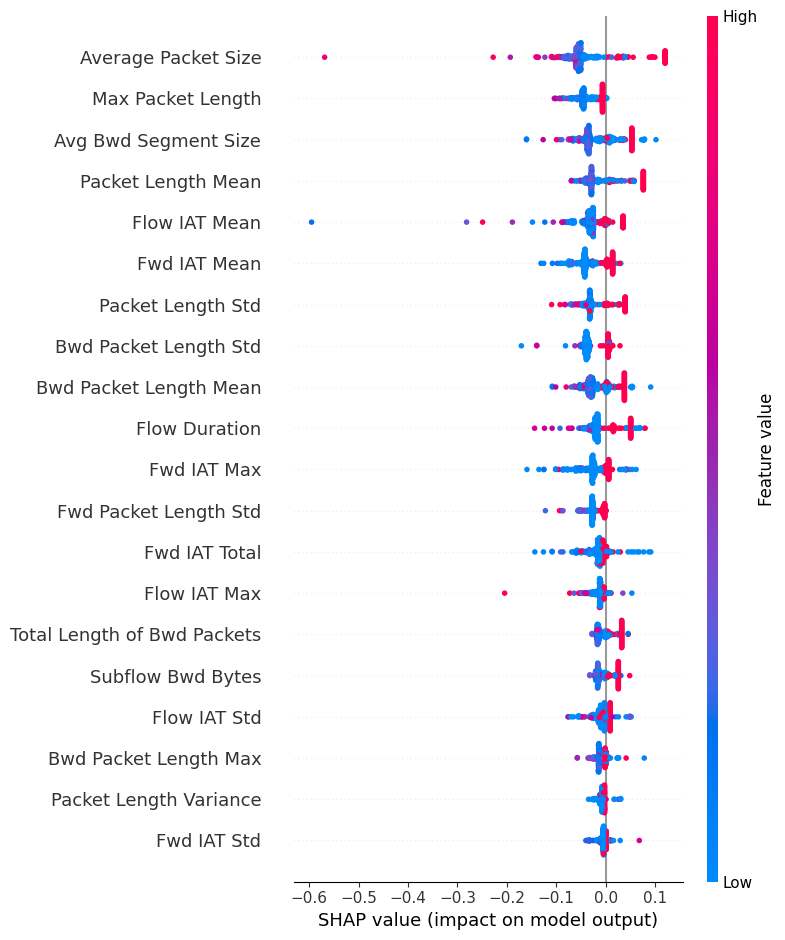

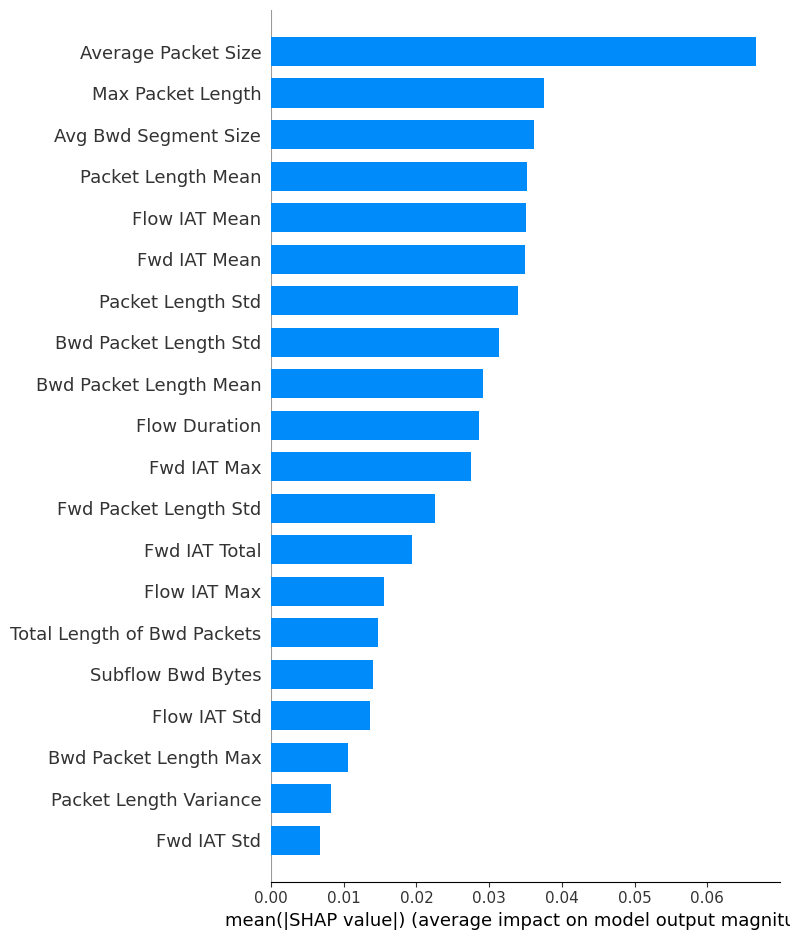

In [46]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

# ensure dataframe
X_small = pd.DataFrame(X_test_scaled[:300], columns=selected_features)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_small)

# 🔥 FIX HERE
if len(shap_values.shape) == 3:
    shap_values = shap_values[:, :, 1]

# summary plot
shap.summary_plot(shap_values, X_small, max_display=20)

plt.savefig('/content/drive/MyDrive/ids_project/report/shap_summary.png', dpi=150, bbox_inches='tight')
plt.close()

# bar plot
shap.summary_plot(shap_values, X_small, plot_type="bar", max_display=20)
plt.savefig('/content/drive/MyDrive/ids_project/report/shap_bar.png', dpi=150, bbox_inches='tight')
plt.close()

In [40]:
import matplotlib.pyplot as plt

shap.summary_plot(shap_values, X_small, max_display=20, show=False)

plt.savefig('/content/drive/MyDrive/ids_project/report/shap_summary.png', dpi=150, bbox_inches='tight')
plt.close()

In [43]:
import numpy as np
import matplotlib.pyplot as plt

i = 0  # sample index

# get correct base value
base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = base_value[1]

# plot
shap.plots._waterfall.waterfall_legacy(
    base_value,
    shap_values[i],
    feature_names=selected_features,
    show=False
)

# save
plt.savefig('/content/drive/MyDrive/ids_project/report/shap_waterfall.png',
            dpi=150, bbox_inches='tight')
plt.close()

In [44]:
shap.dependence_plot(
    selected_features[0],  # or any important feature like 'Flow Duration'
    shap_values,
    X_small,
    show=False
)

plt.savefig('/content/drive/MyDrive/ids_project/report/shap_dependence.png', dpi=150, bbox_inches='tight')
plt.close()